# Algoritmo Genetico - Ejercicio 3
Este notebook retoma la base del Ejercicio 1 para maximizar la funcion cubica f(x) = x^3 - 4x^2 + 5x mediante un algoritmo genetico con codificacion binaria

El objetivo del Ejercicio 3 es analizar como cambia la velocidad y calidad de la convergencia del algoritmo cuando se modifica unicamente la probabilidad de mutacion (pm = 0.01, 0.1 y 0.5), manteniendo todos los demas parametros constantes

In [8]:
import random
import matplotlib.pyplot as plt


Se define el espacio de busqueda de la variable x en el intervalo [-1, 2]
Dentro de este rango la funcion f(x) = x^3 - 4x^2 + 5x tiene un maximo local en x = 1 con f(1) = 2, siendo tambien el maximo global en el rango continuo
El cromosoma se representa como una cadena binaria de longitud fija de 16 bits

In [9]:
LIMITE_INFERIOR = -1.0
LIMITE_SUPERIOR = 2.0
NUM_BITS = 16
TAMANO_POBLACION = 40
NUM_GENERACIONES = 60
PROB_CRUCE = 0.8

Funciones encargadas de transformar la cadena binaria al valor real continuo x y calcular el valor de aptitud fitness

In [10]:
def decodificar(cromosoma):
    entero = int("".join(str(bit) for bit in cromosoma), 2)
    maximo_entero = (2 ** NUM_BITS) - 1
    proporcion = entero / maximo_entero
    x = LIMITE_INFERIOR + proporcion * (LIMITE_SUPERIOR - LIMITE_INFERIOR)
    return x


def funcion_objetivo(x):
    return x**3 - 4 * x**2 + 5 * x


def aptitud(cromosoma):
    x = decodificar(cromosoma)
    return funcion_objetivo(x)


Funciones para la creacion de la poblacion inicial y aplicacion de los operadores de seleccion por torneo, cruce de un punto, mutacion bit a bit y elitismo

In [11]:
def crear_individuo():
    return [random.randint(0, 1) for _ in range(NUM_BITS)]


def crear_poblacion_inicial():
    return [crear_individuo() for _ in range(TAMANO_POBLACION)]


def seleccion_torneo(poblacion, aptitudes, tamano_torneo=3):
    participantes = random.sample(range(len(poblacion)), tamano_torneo)
    mejor_indice = max(participantes, key=lambda i: aptitudes[i])
    return poblacion[mejor_indice][:]


def cruce(padre1, padre2, prob_cruce=PROB_CRUCE):
    if random.random() < prob_cruce:
        punto = random.randint(1, NUM_BITS - 1)
        hijo1 = padre1[:punto] + padre2[punto:]
        hijo2 = padre2[:punto] + padre1[punto:]
        return hijo1, hijo2
    return padre1[:], padre2[:]


def mutacion(cromosoma, prob_mutacion):
    mutado = cromosoma[:]
    for i in range(len(mutado)):
        if random.random() < prob_mutacion:
            mutado[i] = 1 - mutado[i]
    return mutado


def aplicar_elitismo(poblacion, aptitudes, cantidad_elite):
    indices_ordenados = sorted(
        range(len(poblacion)), key=lambda i: aptitudes[i], reverse=True
    )
    elite = [poblacion[i][:] for i in indices_ordenados[:cantidad_elite]]
    return elite


Funcion que ejecuta la evolucion de la poblacion durante el numero de generaciones configurado y retorna el historial de aptitud

In [12]:
def ejecutar_algoritmo_genetico(prob_mutacion, cantidad_elite=1, semilla=None):
    if semilla is not None:
        random.seed(semilla)

    poblacion = crear_poblacion_inicial()
    historial_mejor_aptitud = []

    mejor_aptitud_global = float("-inf")
    mejor_individuo_global = None

    for _ in range(NUM_GENERACIONES):
        aptitudes = [aptitud(individuo) for individuo in poblacion]

        indice_mejor_actual = max(range(len(poblacion)), key=lambda i: aptitudes[i])
        if aptitudes[indice_mejor_actual] > mejor_aptitud_global:
            mejor_aptitud_global = aptitudes[indice_mejor_actual]
            mejor_individuo_global = poblacion[indice_mejor_actual][:]

        historial_mejor_aptitud.append(mejor_aptitud_global)

        nueva_poblacion = aplicar_elitismo(poblacion, aptitudes, cantidad_elite)

        while len(nueva_poblacion) < TAMANO_POBLACION:
            padre1 = seleccion_torneo(poblacion, aptitudes)
            padre2 = seleccion_torneo(poblacion, aptitudes)
            hijo1, hijo2 = cruce(padre1, padre2)
            hijo1 = mutacion(hijo1, prob_mutacion)
            hijo2 = mutacion(hijo2, prob_mutacion)
            nueva_poblacion.append(hijo1)
            if len(nueva_poblacion) < TAMANO_POBLACION:
                nueva_poblacion.append(hijo2)

        poblacion = nueva_poblacion

    mejor_x_global = decodificar(mejor_individuo_global)
    return historial_mejor_aptitud, mejor_individuo_global, mejor_x_global


Evaluacion del impacto de la tasa de mutacion ejecutando el algoritmo con pm = 0.01, 0.1 y 0.5 utilizando la misma semilla aleatoria para comparar la convergencia

[Ejercicio 3] pm=0.01 -> mejor x = 0.9687, mejor f(x) = 1.9990
[Ejercicio 3] pm=0.1 -> mejor x = 1.0000, mejor f(x) = 2.0000
[Ejercicio 3] pm=0.5 -> mejor x = 1.0002, mejor f(x) = 2.0000


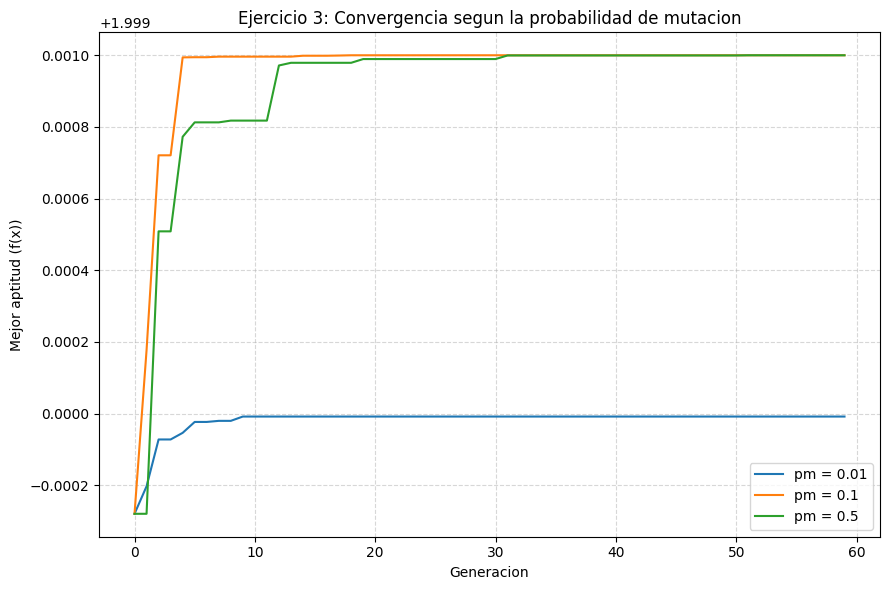

In [13]:
tasas_mutacion = [0.01, 0.1, 0.5]
resultados_ejercicio3 = {}

for pm in tasas_mutacion:
    historial, mejor_individuo, mejor_x = ejecutar_algoritmo_genetico(
        prob_mutacion=pm, cantidad_elite=1, semilla=42
    )
    resultados_ejercicio3[pm] = historial
    print(
        f"[Ejercicio 3] pm={pm} -> mejor x = {mejor_x:.4f}, "
        f"mejor f(x) = {historial[-1]:.4f}"
    )

plt.figure(figsize=(9, 6))
for pm, historial in resultados_ejercicio3.items():
    plt.plot(historial, label=f"pm = {pm}")

plt.title("Ejercicio 3: Convergencia segun la probabilidad de mutacion")
plt.xlabel("Generacion")
plt.ylabel("Mejor aptitud (f(x))")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("ejercicio3_convergencia.png", dpi=150)
plt.show()